## NYC Airbnb Listings Reproducible Data Workflow

- **Author:** Md Hafizur Rahman Bhuia
- **Dataset:** NYC Airbnb Listings
- **Dataset link:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

This project implements a complete, reproducible data-science workflow on the
NYC Airbnb listings dataset. It ingests the data, cleans and transforms it with
documented, reusable functions, runs exploratory analysis, and produces labeled
visualizations, all version-controlled with Git so that the entire workflow can be
rerun from scratch. No machine-learning models are trained; the focus is on a
clean, auditable data pipeline.


# Table of Contents
- [1. Libraries & Setup](#1.-Libraries-&-Setup)
- [2. Data Ingestion](#2.-Data-Ingestion)
- [3. Data Cleaning](#3.-Data-Cleaning)
- [4. Exploratory Data Analysis](#4.-Exploratory-Data-Analysis)
- [5. Visualizations](#5.-Visualizations)
- [6. Summary](#6.-Summary)

---
### 1. Libraries & Setup

In [630]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")



---
### 2. Data Ingestion
Import the libraries above, load the dataset with Pandas, and display the first
few rows to confirm the data loaded correctly.


In [631]:
# Load the local dataset (read-only)
DATA_FILE = Path("data/AB_NYC_2019.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_FILE}. Place the CSV in ./data.")

mb = DATA_FILE.stat().st_size / 1e6
load_date = datetime.now().strftime("%Y-%m-%d %H:%M")

df = pd.read_csv(DATA_FILE)

print(f"Loaded {DATA_FILE.name} -> {mb:.2f} MB on {load_date}")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded AB_NYC_2019.csv -> 7.08 MB on 2026-09-05 19:19
Dataset shape: 48895 rows, 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
### 3. Data Cleaning
In this section, we perform data cleaning. First, let's check for duplicates and missing values:

In [632]:
print("No of duplicates:", df.duplicated().sum())

No of duplicates: 0


In [633]:
print(f"Missing values per column:\n{df.isna().sum()}")

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [635]:
print("Number of records with `number_of_reviews` == 0:", len(df[df["number_of_reviews"] == 0]))
print("Number of records with missing `reviews_per_month`:", len(df[df["reviews_per_month"].isna()]))

Number of records with `number_of_reviews` == 0: 10052
Number of records with missing `reviews_per_month`: 10052


As `number_of_reviews` column is synced with missing `reviews_per_month` records, imputation is deemed unnecessary for `reviews_per_month` column. 

#### 3.1 Drop `price` outliers
Next, we check for outliers in the numerical field price.

In [590]:
df[['price']].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


It turns out that there are far outliers in `price` field, which would distort correlation analysis and impede boxplot visualizations. We therefore remove them by cutting off at the 0.5% and 99.5% quantile:

In [591]:
price005 = np.quantile(df.price, q=0.005)
print(f'price 0.5% quantile: {price005}')
price995 = np.quantile(df.price, q=0.995)
print(f'price 99.5% quantile: {price995}')

price 0.5% quantile: 26.0
price 99.5% quantile: 1000.0


In [592]:
def clean_outliers(df, col, qLower, qUpper):
    """
    A function that removes outliers in a given columns, as specified by lower and upper cutoff values.
    
    Args:
        df (dataframe): The Pandas dataframe
        col (str): The column name
        qLower (float): The lower cutoff value
        qUpper (float): The upper cutoff value
        
    Returns:
        pandas.DataFrame
            A copy of the frame with outliers removed.
    """
    indices_to_drop = df[(df[col] < qLower) | (df[col] > qUpper)].index

    print(f"Dropped {indices_to_drop.size} outlier rows "
      f"({100*indices_to_drop.size/len(df):.2f}% of data)")

    df = df.drop(indices_to_drop)
    
    return df

In [593]:
df = clean_outliers(df, 'price', price005, price995)

Dropped 468 outlier rows (0.96% of data)


#### 3.2 Drop `shared room`s
There are not rentable rooms that are marked as `shared room` and should be removed from the dataset.

In [594]:
df_not_rentable = df[df["room_type"].str.lower().str.contains("shared room", na=False)]
print("Not rentable rooms:", len(df_not_rentable))

Not rentable rooms: 1047



**Dropping `shared room` listings** refocuses the analysis on whole-property nightly rates; this is a deliberate scope choice, not a data-loss issue.

In [595]:
def clean_non_rentable(df):
    """Drop non-rentable listing rows.

    This removes listings whose property type is not rentable by guests (e.g., shared rooms).

    Args:
        df (pandas.DataFrame): Raw loaded dataset containing, at minimum, a 'room_type' column.

    Returns:
        pandas.DataFrame: A copy of the frame with non-rentable listings removed.
    """
    if "room_type" in df.columns:
        df = df[~df["room_type"].str.lower().str.contains("shared room", na=False)]

    return df


In [596]:
df = clean_non_rentable(df)

print("Rows after cleaning:", len(df))
df.head()


Rows after cleaning: 47380


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
### 4. Exploratory Data Analysis


#### 4.1 Correlation Statistics

Let's find the correlation between price and other variables.

##### 4.1.1 Spearman (numeric → price)

Spearman's ρ measures **monotonic** association on a scale from −1 to +1. It's rank-based, so it only cares about whether two variables move together in order, not about exact values.

In [597]:
numeric_cols = ["minimum_nights", "number_of_reviews", "availability_365"]

spearman_price_corr = (
    df[numeric_cols + ["price"]]
    .corr(method="spearman")["price"]
    .drop("price")
).sort_values(ascending=False)

spearman_price_df = pd.DataFrame(
    spearman_price_corr.items(),
    columns=["Variable", "ρ"]
).set_index("Variable")

spearman_price_df["ρ² (% variance explained)"] = (
    spearman_price_df["ρ"]
    .apply(lambda x: f"{x**2 * 100:.2f}%")
)

spearman_price_df


,ρ,ρ² (% variance explained)
Variable,,
availability_365,0.099405,0.99%
minimum_nights,0.098332,0.97%
number_of_reviews,-0.054409,0.30%


##### 4.1.2 Correlation ratio η (categorical → price)

The correlation ratio η measures how well a **categorical** variable predicts a **numeric** one. It is computed as

$$\eta = \sqrt{\frac{\text{between-group sum of squares}}{\text{total sum of squares}}}$$

So **η² is directly interpretable: it is the proportion of price variance explained by grouping on that variable** (the η² effect size from a one-way ANOVA), ranging 0–1.

In [598]:
def correlation_ratio(categories, values):
    cat = np.unique(categories)
    y_mean = np.mean(values)
    numerator = sum([len(values[categories == k]) * 
                     (np.mean(values[categories == k]) - y_mean)**2 for k in cat])
    denominator = sum((values - y_mean)**2)
    return numerator / denominator

categorical_cols = ["neighbourhood_group", "room_type"]

eta_price = []

for cat in categorical_cols:
    correlation = correlation_ratio(df[cat], df["price"])
    
    eta_price.append((f"{cat} → price", correlation, f"{correlation ** 2 * 100:.2f}%"))

eta_df = pd.DataFrame(eta_price, columns=["Variable", "η", "η² (% variance explained)"]).set_index("Variable")
eta_df

,η,η² (% variance explained)
Variable,,
neighbourhood_group → price,0.087748,0.77%
room_type → price,0.219467,4.82%


`room_type` is by far the strongest single predictor — entire homes/apt command materially higher rates than private rooms, which matches your boxplots and grouped medians.

##### Observations
**How much does each feature explain on its own?**
- Because the correlation and eta statistics live on different scales, I square each to
put them on a common yardstick: **the proportion of price variance explained by that
variable alone** (for Spearman, ρ² is a monotonic association measure; for the correlation
ratio, η² is exactly the ANOVA effect size).
* Every feature except `room_type` explains **under 1%** of price variance on its
own. `room_type` is the lone outlier at ~5% — entire homes/apt consistently outprice private
rooms. `minimum_nights`, `availability_365`, and `reviews_per_month` are all negligible here.

**Why is neighbourhood's η² so small (0.77%) despite the clear Manhattan–Bronx gradient?**
* Because price is heavily right-skewed, the within-group spread and the extreme tail inflate
the denominator of η, shrinking it. The median gap is real and visually clear
(Figures 1–2); the ratio is computed on **means**, which skew badly under this distribution.
Reporting medians (as in the grouped statistics and plots below) is the more honest summary.

#### 4.2 Group Statistics

Next, we look at the categorial columns neighbourhood_group and room_type by producing grouped descriptive statistics:

In [599]:

def get_grouped_stats(df, stat_col, by_col):
    """
    A function that calculates descriptive statistics for a column in a dataframe, grouped by another column.
    
    Args:
        df (dataframe): The Pandas dataframe
        stat_col (str): Name of the column, for which stats are calculated
        by_col (str): Name of the column, by which data are grouped
        
    Returns:
        dataframe: A dataframe containing the grouped statistics
    """
    grouped = df.groupby(by=by_col)[stat_col]

    stats = grouped.describe()
    stats["median"] = grouped.median()

    return stats

In [600]:
get_grouped_stats(df, 'price', 'neighbourhood_group')

,count,mean,std,min,25%,50%,75%,max,median
neighbourhood_group,,,,,,,,,
Bronx,1018.0,87.546169,76.037306,26.0,49.0,69.0,100.0,1000.0,69.0
Brooklyn,19579.0,119.520966,94.546437,26.0,60.0,95.0,150.0,1000.0,95.0
Manhattan,20985.0,181.179700,133.951001,26.0,98.0,150.0,220.0,1000.0,150.0
Queens,5439.0,96.765214,73.808851,26.0,53.0,75.0,115.0,1000.0,75.0
Staten Island,359.0,100.253482,97.019982,27.0,50.0,75.0,110.0,1000.0,75.0


In [601]:
get_grouped_stats(df, 'price', 'room_type')

,count,mean,std,min,25%,50%,75%,max,median
room_type,,,,,,,,,
Entire home/apt,25195.0,194.762493,126.049295,28.0,120.0,160.0,225.0,1000.0,160.0
Private room,22185.0,85.036511,68.750757,26.0,50.0,70.0,95.0,1000.0,70.0


#### Observations

* By neighbourhood, median nightly price rises with borough demand: Manhattan (150) > Brooklyn (95) > Queens (75) = Staten Island (75) > Bronx (69). Manhattan's mean (≈181) is nearly double the Bronx's (≈88).
* By room type, entire homes (median 160, mean≈195) are roughly **2–3× more expensive** than private rooms (median 70, mean ≈85).
* Every group's median sits well below its mean and its standard deviation is large relative to the mean — the signature of the right-skew that justifies reporting the median.
* Staten Island (359 listings) and the Bronx (1,018) have the fewest listings, so their medians are the least stable.

**Takeaway:** `room_type` and, to a lesser extent, neighbourhood carry the largest *relative*
signal — but even the strongest single feature explains less than 5% of price variance. Price is
driven more by the wide spread **within** each category (a luxury tail, unmodeled here) than by
these features alone, which is exactly why a model would need more predictors than any of these
univariate measures.


---
### 5. Visualizations

#### 5.1 Univariate Plots
We first look at univariate distributions of the variables under consideration.

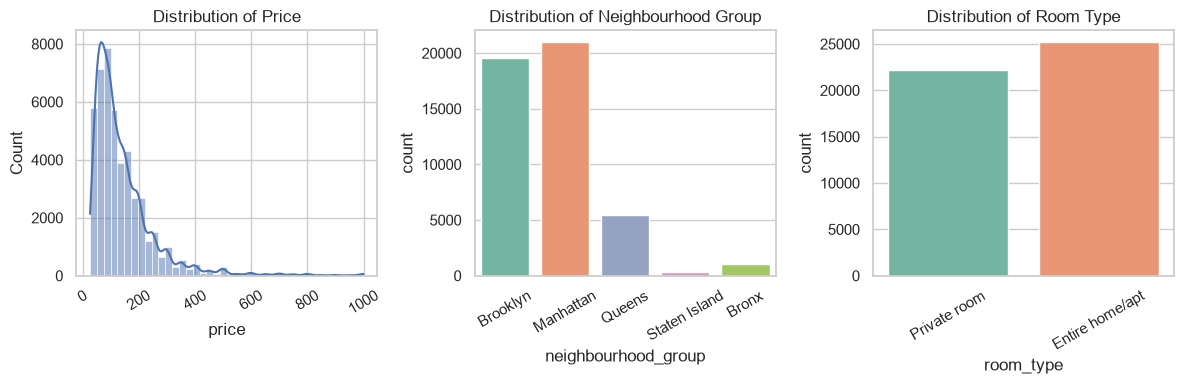

In [602]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(df['price'], ax=axes[0], bins=40, kde=True)
axes[0].set_title("Distribution of Price")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(
    x="neighbourhood_group",
    hue="neighbourhood_group",
    data=df, ax=axes[1],
    palette="Set2",
    legend=False
)
axes[1].set_title("Distribution of Neighbourhood Group")
axes[1].tick_params(axis='x', rotation=30)

sns.countplot(
    x="room_type",
    hue="room_type",
    data=df,
    ax=axes[2],
    palette="Set2",
    legend=False
)
axes[2].set_title("Distribution of Room Type")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("charts/fig_record_distributions.png", dpi=120)
plt.show()


**Observations:**
* The price histogram is heavily right-skewed: the mode lies below USD 100–150,
  while the long tail contains a small number of high-end listings (after clipping,
  roughly USD [0.995 quantile value]). This asymmetry justifies using the median,
  not the mean, as the measure of typical price.
* Listings concentrate in Manhattan and Brooklyn, with substantially fewer in
  Queens, and comparatively few in the Bronx and Staten Island.
* "Entire home/apt" and "Private room" are the two dominant room types and are
  present in similar numbers.

#### 5.2 Bivariate Plots
Next we look at bivariate plots, visualizing the dependence of price on the other variables.

##### 5.2.1 Median Nightly Airbnb Price by Neighbourhood Group

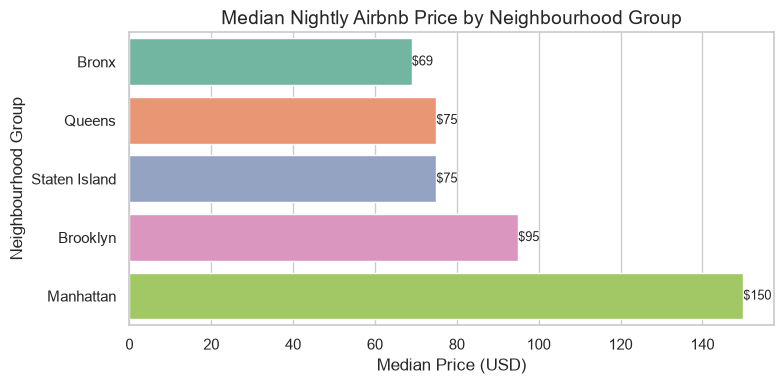

In [603]:
fig, ax = plt.subplots(figsize=(8, 4))

group_stats = df.groupby("neighbourhood_group")["price"].agg(["median", "std"])
group_stats = group_stats.sort_values("median")

sns.barplot(
    data=group_stats.reset_index(),
    y="neighbourhood_group",
    x="median",
    hue="neighbourhood_group",
    palette="Set2",
    legend=False,
    ax=ax
)

for i, row in group_stats.iterrows():
    ax.text(row["median"], i, f"${row['median']:,.0f}",
            va="center", ha="left", fontsize=9)

ax.set_title("Median Nightly Airbnb Price by Neighbourhood Group", fontsize=14)
ax.set_xlabel("Median Price (USD)")
ax.set_ylabel("Neighbourhood Group")

plt.tight_layout()
plt.savefig("charts/fig_median_price_by_neighbourhood.png", dpi=120)
plt.show()

**Observations:**
* Median nightly price is highest in Manhattan (USD 150) and lowest in the Bronx
  (USD 69), with a clear, ordered gradient across the five boroughs.
* This gradient reflects the concentration of tourist demand and high-value
  neighborhoods in Manhattan; the smaller medians in the outer boroughs indicate
  more affordable housing stock.

##### 5.2.2 Price Distribution by Neighbourhood Group

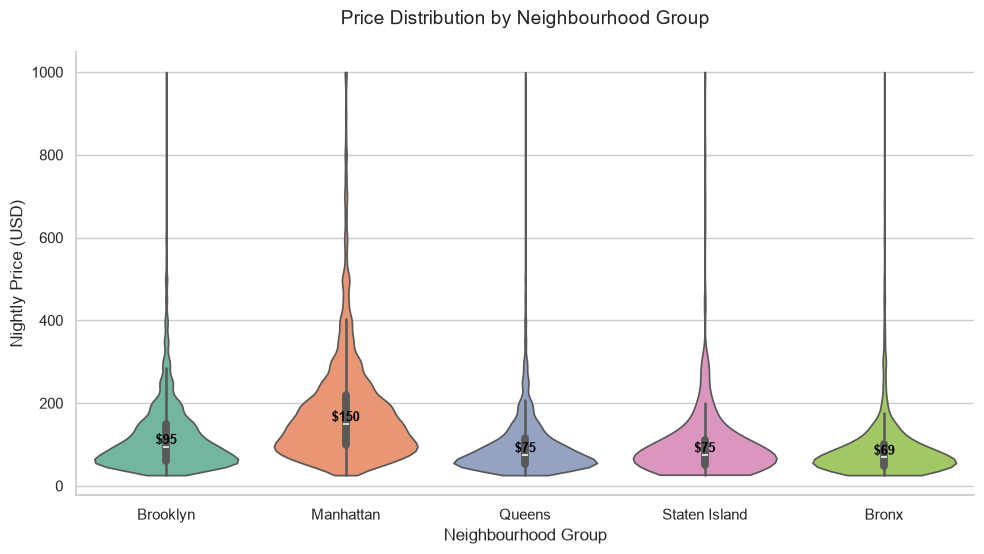

In [604]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",
    palette="Set2",
    dodge=False,
    inner="box",
    cut=0,
    density_norm="width",
    legend=False,
    ax=ax
)

# Compute medians
medians = df.groupby("neighbourhood_group")["price"].median()

# Adjust label placement dynamically
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    group = label.get_text()
    median_val = medians[group]
    ax.text(
        tick,
        median_val,
        f"${median_val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

#
ax.set_title("Price Distribution by Neighbourhood Group", fontsize=14, pad=20)
ax.set_xlabel("Neighbourhood Group", fontsize=12)
ax.set_ylabel("Nightly Price (USD)", fontsize=12)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leaves extra space for title
plt.savefig("charts/fig_price_distribution_by_neighbourhood.png", dpi=120)
plt.show()



**Observations:**
* Every borough's price distribution is strongly right-skewed, confirming the long
  upper tail seen in the histogram.
* Manhattan and Brooklyn show the widest price distributions (supporting a range of
  listings from budget to luxury), whereas the Bronx and Staten Island are tightly
  clustered around lower prices.

##### 5.2.3 Price by Property Type Across Neighbourhood Groups

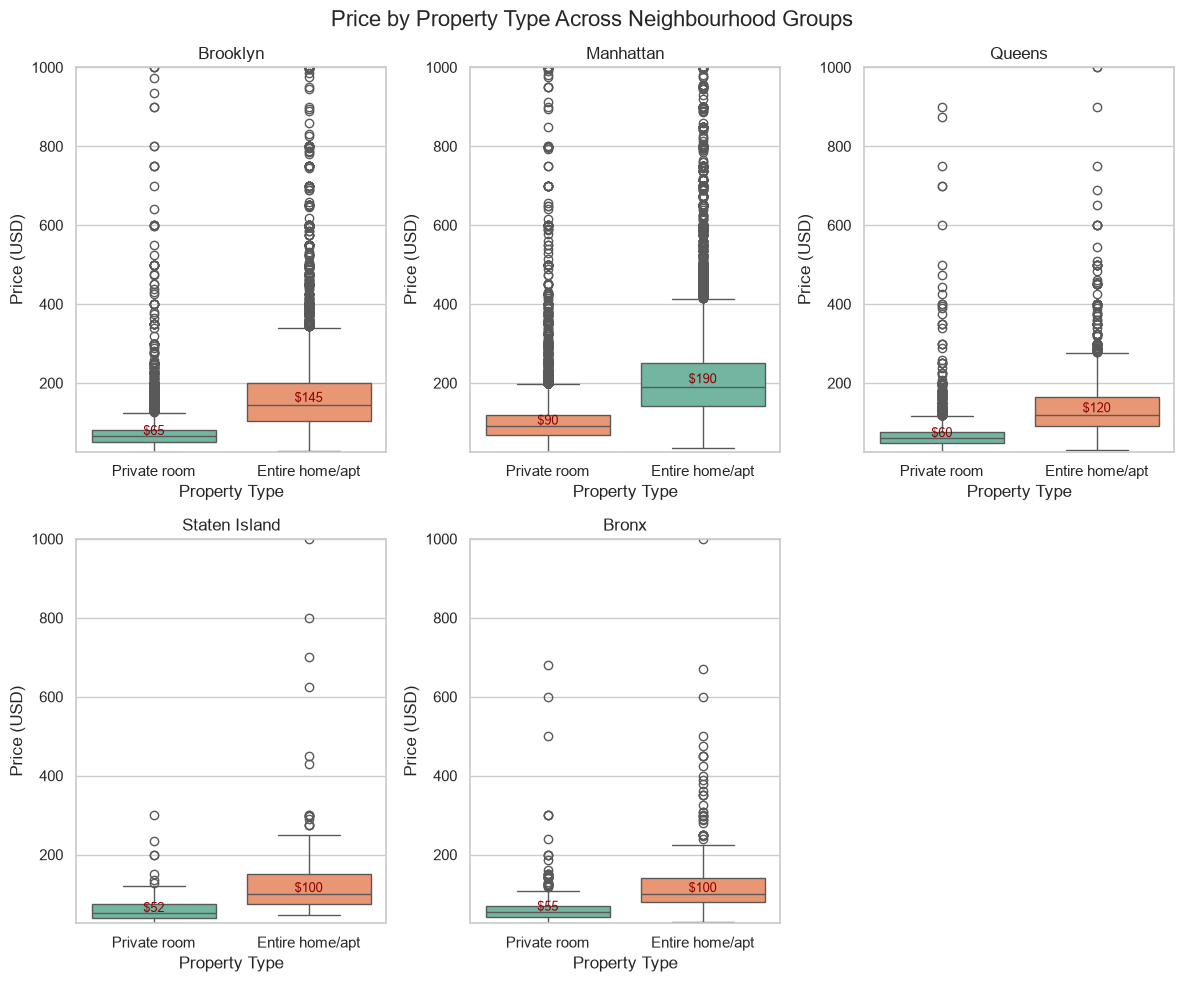

In [605]:
# Compute medians for annotation
medians = df.groupby(["neighbourhood_group", "room_type"])["price"].median().unstack()

groups = ["Brooklyn", "Manhattan", "Queens", "Staten Island", "Bronx"]
order = ["Private room", "Entire home/apt"]

# Compute global y-axis limits
ymin = df["price"].min()
ymax = df["price"].max()

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    subset = df[df["neighbourhood_group"] == group]

    sns.boxplot(
        data=subset,
        x="room_type",
        y="price",
        hue="room_type",
        order=order,
        palette="Set2",
        showfliers=True,
        legend=False,
        ax=ax
    )

    ax.set_title(group)
    ax.set_xlabel("Property Type")
    ax.set_ylabel("Price (USD)")
    ax.tick_params(axis="x", rotation=0)

    # Apply uniform y-axis scale
    ax.set_ylim(ymin, ymax)

    # Add median annotations
    for i, room in enumerate(order):
        val = medians.loc[group, room]
        if not np.isnan(val):
            ax.text(
                i,
                val + (val * 0.05),
                f"${val:.0f}",
                ha="center",
                fontsize=9,
                color="darkred"
            )

# Remove empty subplot (6th)
fig.delaxes(axes[-1])

fig.suptitle("Price by Property Type Across Neighbourhood Groups", fontsize=16)
plt.savefig("charts/fig_price_by_property_type_across_neighbourhoods.png", dpi=120)
plt.tight_layout()
plt.show()


**Observations:**
* Within each borough, "Entire home/apt" listings command a higher median than"Private room" listings.
* This property-type stratification holds across all boroughs but is most pronounced in Manhattan, where entire-home prices reach the top of the scale.
* Together, Figures 5.2.1–5.2.3 show that **both location (neighbourhood) and property type independently raise price**, with Manhattan's location effect dominating.

---
### 6. Summary

**What I learned:**
* The dataset captures the economics of short-term rentals in NYC.
* Location (neighbourhood group) and property type are the two strongest predictors of nightly price:
    * Manhattan consistently commands the highest median rate,
    * and "Entire home/apt" listings outprice private shared rooms.
* The heavy right-skew in price confirms the median is the appropriate measure of central tendency.

**Limitations:**
* Outlier clipping at the 0.5%/99.5% quantiles discards roughly 1% of listings and truncates the heavy price tail, so summary statistics no longer include the most
  expensive properties.
* Removing "shared room" listings narrows the population to whole-property rentals, so results describe that segment rather than all NYC Airbnb.

**Surprising / unclear.**
* Despite the price distribution's skew, the majority of listings remain affordable (median well below USD 190).
* A large share of listings have no reviews, which is unusual given the market's size — possibly reflecting a recent or long-vacant listing.
* The Bronx and Staten Island have very few listings, making their medians more sensitive to outliers and less stable.